# Implementing ANNs with TensorFlow - Homework 06 (Group 4)

## Assignment: CIFAR-10 Classification (Part II)

### Preparing the data set

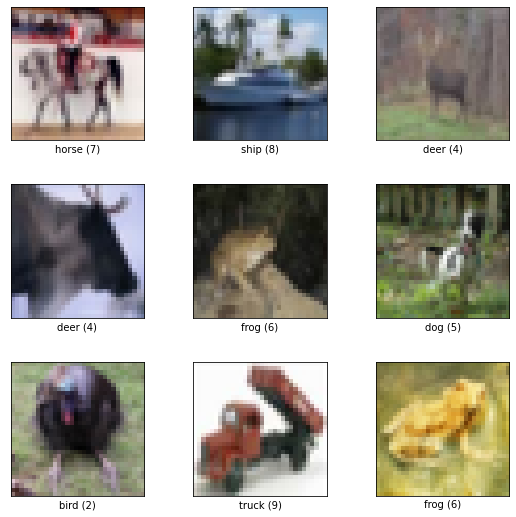

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the data
(train_ds, test_ds), ds_info = tfds.load("cifar10", split=["train", "test"], as_supervised=True, with_info=True)
# inspect the data: images of shape (32, 32, 3) representing ten non-overlapping classes
tfds.show_examples(train_ds, ds_info)
# take only a subset of the data to speed up the training process
train_ds = train_ds.take(10000)
test_ds = test_ds.take(1000)

In [3]:
def augment_data(cifar_10, training):
  """
  This function randomly rotates the images of the dataset during training in order to achieve better generalization.

  Arguments:
  cifar_10 -- (a subset of) the CIFAR-10 dataset
  training -- a boolean indicating whether we are in the training stage
  """
  # function to flip the images horizontally
  augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"), tf.keras.layers.RandomRotation(0.3),])
  # apply rotation to the dataset
  cifar_10 = cifar_10.map(lambda img, target: (augmentation(img, training=training), target))

  return cifar_10

In [4]:
def prepare_data(cifar_10, batch_size=32):
  """
  This function is used to prepare the raw data for training and testing.

  Arguments:
  cifar_10 -- (a subset of) the CIFAR-10 dataset
  batch_size -- denotes the batch size (default is 32)
  """
  # convert images to float32 data type
  cifar_10 = cifar_10.map(lambda img, target: (tf.cast(img, tf.float32), target))
  # normalize the data by projecting the pixel values into range [-1, 1]
  cifar_10 = cifar_10.map(lambda img, target: (tf.cast(tf.image.per_image_standardization(img), tf.float32), target))
  # represent targets as one-hot vectors (depth=10 as there are ten possible classifications)
  cifar_10 = cifar_10.map(lambda img, target: (img, tf.one_hot(target, depth=10)))

  # cache progress into memory
  cifar_10 = cifar_10.cache()
  # shuffle the data into a random order
  cifar_10 = cifar_10.shuffle(1000)
  # use batches of a given size
  cifar_10 = cifar_10.batch(batch_size)
  # prefetch some data points
  cifar_10 = cifar_10.prefetch(tf.data.AUTOTUNE)

  return cifar_10

# transform the training and test data
train_dataset = train_ds.apply(prepare_data)
test_dataset = test_ds.apply(prepare_data)

### Building the CNN model

In [5]:
class ConvModel(tf.keras.Model):
  """
  This subclass of the keras model builds our neural network.
  """
  def __init__ (self, layer_config):
    """
    The constructor initiates the layers and their activation functions.

    Arguments:
    layer_config -- a list of convolutional and pooling layers
    optimizer -- denotes the model optimizer
    """
    # call the parent constructor
    super().__init__()
    # use categorical crossentropy loss since the data holds more than two classes
    self.loss_function = tf.keras.losses.CategoricalCrossentropy()
    # use Adam as our optimizer
    self.optimizer = tf.keras.optimizers.Adam()
    # instantiate the layers according to a given architecture
    self.conv_layers = layer_config
    # instantiate the output layer with softmax as activation function
    self.output_layer = tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    # instantiate metric objects to keep track of the training/test loss and accuracy
    self.loss_metric = tf.keras.metrics.Mean(name="loss") 
    self.accuracy_metric = tf.keras.metrics.CategoricalAccuracy(name="accuracy")

  @tf.function
  def call(self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    # feed the input through the network
    output = self.conv_layers[0](input)
    for layer in self.conv_layers[1:]:
      output = layer(output)
    output = self.output_layer(output)

    return output

  def reset_metrics(self):
    """
    This function will reset the metric objects after every training epoch.
    """
    for metric in self.metrics:
      metric.reset_states()

  @tf.function
  def train_step(self, input):
    """
    This function defines a step during the training process
    Updates and returns the loss and accuracy metrics after the training step.

    Arguments:
    input -- the input tensors (img, target) to the model
    """
    img, target = input
    with tf.GradientTape() as tape:
      # create the prediction
      prediction = self(img)
      # calculate the loss
      loss = self.loss_function(target, prediction) + tf.reduce_sum(self.losses)
    # calculate the gradients
    gradients = tape.gradient(loss, model.trainable_variables)
    # apply the gradients
    self.optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    # update the metrics
    self.loss_metric.update_state(loss)
    self.accuracy_metric.update_state(target, prediction)

    return self.loss_metric.result(), self.accuracy_metric.result()

  @tf.function
  def test(self, test_data):
    """
    A function to test how the model performs on the given data.
    Returns the loss and accuracy metrics.

    Arguments:
    test_data -- the data used for testing
    """
    # unpack the the test data
    img, target = test_data
    # create prediction
    prediction = self(img)
    # calculate loss
    loss = self.loss_function(target, prediction) + tf.reduce_sum(self.losses)
    # update the metrics
    self.loss_metric.update_state(loss)
    self.accuracy_metric.update_state(target, prediction)

    return self.loss_metric.result(), self.accuracy_metric.result()

### Training the network

In [6]:
def training(model, n_epochs, train_dataset, test_dataset):
  """
  Defines the training process of our neural network.
  Returns the training losses and accuracies as a dictionary.

  Arguments:
  model -- the model object representing our neural network
  n_epochs -- the number of training steps
  train_dataset -- denotes the training dataset
  test_dataset -- denotes the test dataset
  """
  # lists to track training/test losses and accuracies
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # check how our model performs on training data before training
  for data in train_dataset:
    train_loss, train_accuracy = model.test(data)
  train_losses.append(train_loss.numpy())
  train_accuracies.append(train_accuracy.numpy())
  
  model.reset_metrics()
  
  # check how our model performs on test data before training
  for data in test_dataset:
    test_loss, test_accuracy = model.test(data)
  test_losses.append(test_loss.numpy())
  test_accuracies.append(test_accuracy.numpy())

  model.reset_metrics()

  print("Training progress: \n")

  # train for given number of epochs
  for epoch in range(n_epochs):
    # print the accuracy after the current epoch
    print(f'Epoch {str(epoch)} started with accuracy {test_accuracies[-1]}')

    # train the network
    for data in train_dataset:
      train_loss, train_accuracy = model.train_step(data)
    # store training loss and accuracy
    train_losses.append(train_loss.numpy())
    train_accuracies.append(train_accuracy.numpy())

    # reset the model metrics
    model.reset_metrics()

    # test the network
    for data in test_dataset:
      test_loss, test_accuracy = model.test(data)
    # store test loss and accuracy
    test_losses.append(test_loss.numpy())
    test_accuracies.append(test_accuracy.numpy())

    # again reset the model metrics
    model.reset_metrics()

  return train_losses, train_accuracies, test_losses, test_accuracies

In [7]:
tf.keras.backend.clear_session()
# hyperparameters for the training process
# train for 10 epochs
num_epochs = 10
# base model (taken from lecture material)
layers = [tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"), 
          tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
          tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu"),
          tf.keras.layers.GlobalAvgPool2D()]
# instantiate the model
model = ConvModel(layer_config=layers)
# train the base model
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs, train_dataset, test_dataset)

Training progress: 

Epoch 0 started with accuracy 0.06400000303983688
Epoch 1 started with accuracy 0.3050000071525574
Epoch 2 started with accuracy 0.38199999928474426
Epoch 3 started with accuracy 0.4490000009536743
Epoch 4 started with accuracy 0.4690000116825104
Epoch 5 started with accuracy 0.5130000114440918
Epoch 6 started with accuracy 0.5149999856948853
Epoch 7 started with accuracy 0.5590000152587891
Epoch 8 started with accuracy 0.5270000100135803
Epoch 9 started with accuracy 0.5860000252723694


### Visualization

In [8]:
def visualization(train_losses, train_accuracies, test_losses, test_accuracies, n_epochs=10):
  """
  This function visualizes the training progress by showing the mean losses and accuracies after each epoch.
  This time, we will use the seaborn package.

  Arguments:
  train_losses -- denotes the recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  n_epochs -- the number of training epochs (default is 10)
  """
  # create column vectors for a Pandas dataframe
  epochs = 4 * list(range(n_epochs+1))
  results = train_losses + test_losses + train_accuracies + test_accuracies
  stage = 2* (["Training" for _ in range(11)] + ["Test" for _ in range(11)])
  metric = ["Loss" for _ in range(2*(n_epochs+1))] + ["Accuracy" for _ in range(2*(n_epochs+1))]
  # create Pandas dataframe
  df = pd.DataFrame({"Epochs": epochs, "Results": results, "Metric": metric, "Stage": stage})
  # create lineplot where colour is given by stage and pattern is determined by metric
  sns.relplot(data=df, x="Epochs", y="Results", hue="Stage", style="Metric", kind="line")

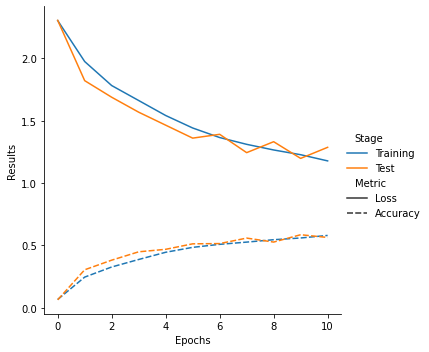

In [9]:
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

### Optimising the CNN Model

Optimisation techniques:

1.   Data augmentation via random rotation of training images
2.   Use of the Glorot Normal kernel initializer
3.   Use of the L2 kernel regularizer
4.   Batch normalization
5.   Use of dropout layer


Training progress: 

Epoch 0 started with accuracy 0.08699999749660492


Epoch 1 started with accuracy 0.3779999911785126
Epoch 2 started with accuracy 0.43700000643730164
Epoch 3 started with accuracy 0.4410000145435333
Epoch 4 started with accuracy 0.4189999997615814
Epoch 5 started with accuracy 0.4690000116825104
Epoch 6 started with accuracy 0.45899999141693115
Epoch 7 started with accuracy 0.4690000116825104
Epoch 8 started with accuracy 0.5
Epoch 9 started with accuracy 0.5040000081062317


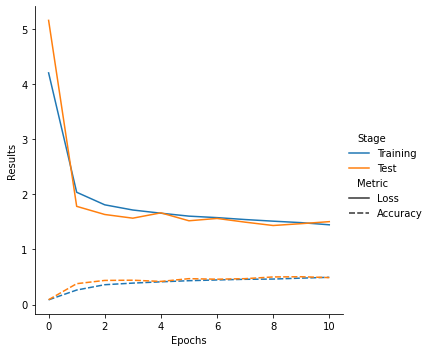

In [10]:
tf.keras.backend.clear_session()

# use augmented training and test data
augmented_train_dataset = augment_data(train_ds, training=True)
augmented_test_dataset = augment_data(test_ds, training=False)
augmented_train_dataset = augmented_train_dataset.apply(prepare_data)
augmented_test_dataset = augmented_test_dataset.apply(prepare_data)
# use the Glorot Normal kernel initializer
initializer = tf.keras.initializers.GlorotNormal()
# use the L2 kernel regularizer
kernel_regularizer=tf.keras.regularizers.L2()
# run training with augmented dataset and visualize results
aug_model = ConvModel(layer_config=layers)
train_losses, train_accuracies, test_losses, test_accuracies = training(aug_model, num_epochs, augmented_train_dataset, augmented_test_dataset)
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

Training progress: 

Epoch 0 started with accuracy 0.08100000023841858


Epoch 1 started with accuracy 0.49399998784065247
Epoch 2 started with accuracy 0.5109999775886536
Epoch 3 started with accuracy 0.5550000071525574
Epoch 4 started with accuracy 0.5410000085830688
Epoch 5 started with accuracy 0.5979999899864197
Epoch 6 started with accuracy 0.5860000252723694
Epoch 7 started with accuracy 0.5770000219345093
Epoch 8 started with accuracy 0.6140000224113464
Epoch 9 started with accuracy 0.6240000128746033


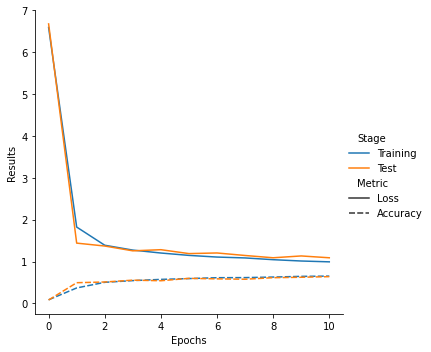

In [11]:
tf.keras.backend.clear_session()

# define the layer configuration involving dropout layers (+ kernel initialization and regularization)
dropout_config = [tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.Dropout(0.1),
                  tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
                  tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.Dropout(0.1),
                  tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.GlobalAvgPool2D()]

# instantiate and train the dropout model, then visualize the results
dropout_model = ConvModel(layer_config=layers)
train_losses, train_accuracies, test_losses, test_accuracies = training(dropout_model, num_epochs, train_dataset, test_dataset)
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

Training progress: 

Epoch 0 started with accuracy 0.11500000208616257


Epoch 1 started with accuracy 0.4860000014305115
Epoch 2 started with accuracy 0.527999997138977
Epoch 3 started with accuracy 0.5619999766349792
Epoch 4 started with accuracy 0.597000002861023
Epoch 5 started with accuracy 0.6010000109672546
Epoch 6 started with accuracy 0.628000020980835
Epoch 7 started with accuracy 0.6240000128746033
Epoch 8 started with accuracy 0.6269999742507935
Epoch 9 started with accuracy 0.6499999761581421


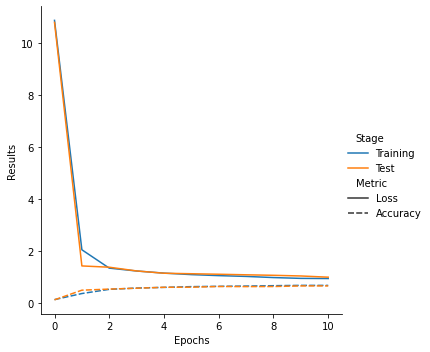

In [12]:
tf.keras.backend.clear_session()

# define the layer configuration using batch normalization
batch_norm_config = [tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.BatchNormalization(),
                  tf.keras.layers.Conv2D(filters=24, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.MaxPooling2D(pool_size=2, strides=2),
                  tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.BatchNormalization(),
                  tf.keras.layers.Conv2D(filters=48, kernel_size=3, padding="same", activation="relu", kernel_initializer=initializer, kernel_regularizer=kernel_regularizer),
                  tf.keras.layers.GlobalAvgPool2D()]

# instantiate and train the batchnorm model, then visualize the results
batchnorm_model = ConvModel(layer_config=layers)
train_losses, train_accuracies, test_losses, test_accuracies = training(batchnorm_model, num_epochs, train_dataset, test_dataset)
visualization(train_losses, train_accuracies, test_losses, test_accuracies)